<h1 style="align:center"></h1>
<div align="center">
<h1><b><u>Project A.D.I.T.I.</b></u></h1>
</div>

In [1]:
# pull dataset from github repo
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 27.51 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [2]:
color_dataset = "/content/PlantVillage-Dataset/raw/color"

segmented_dataset = "/content/PlantVillage-Dataset/raw/segmented"

In [3]:
# we'll train model on color or segmented but basd on that if segmented performs bettr we'll need to process color to segmented image

In [4]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 5.9 MB/s eta 0:00:00


In [5]:
import torch
import torch.nn as nn
import snntorch
from snntorch import spikeplot as splt
from snntorch import functional as SF
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print(f"snntorch version: {snntorch.__version__}")
print(f"torch version: {torch.__version__}")

snntorch version: 0.9.4
torch version: 2.10.0+cu128


In [6]:
import os
import glob

# 1. Define base repository path
base_repo = "/content/PlantVillage-Dataset"

# 2. Use glob for recursive search for 'color' folder
# 3. Search pattern to look for any folder named 'color' within the repo
search_pattern = os.path.join(base_repo, '**', 'color')
found_paths = [p for p in glob.glob(search_pattern, recursive=True) if os.path.isdir(p)]

if found_paths:
    # 4. Store discovered path in final_color_path
    final_color_path = found_paths[0]

    # 5. Print and verify existence
    print(f"Final color path: {final_color_path}")
    print(f"Path exists: {os.path.exists(final_color_path)}")

    # 6. List subdirectories to confirm classes
    classes = [d for d in os.listdir(final_color_path) if os.path.isdir(os.path.join(final_color_path, d))]
    print(f"Found {len(classes)} classes.")
    print("Class samples:", classes[:5])
else:
    print("Error: 'color' directory not found. Please ensure the repository was cloned correctly.")
    final_color_path = None

Final color path: /content/PlantVillage-Dataset/raw/color
Path exists: True
Found 38 classes.
Class samples: ['Tomato___Spider_mites Two-spotted_spider_mite', 'Grape___Esca_(Black_Measles)', 'Strawberry___healthy', 'Apple___Cedar_apple_rust', 'Cherry_(including_sour)___healthy']


## Data Exploration and Analysis

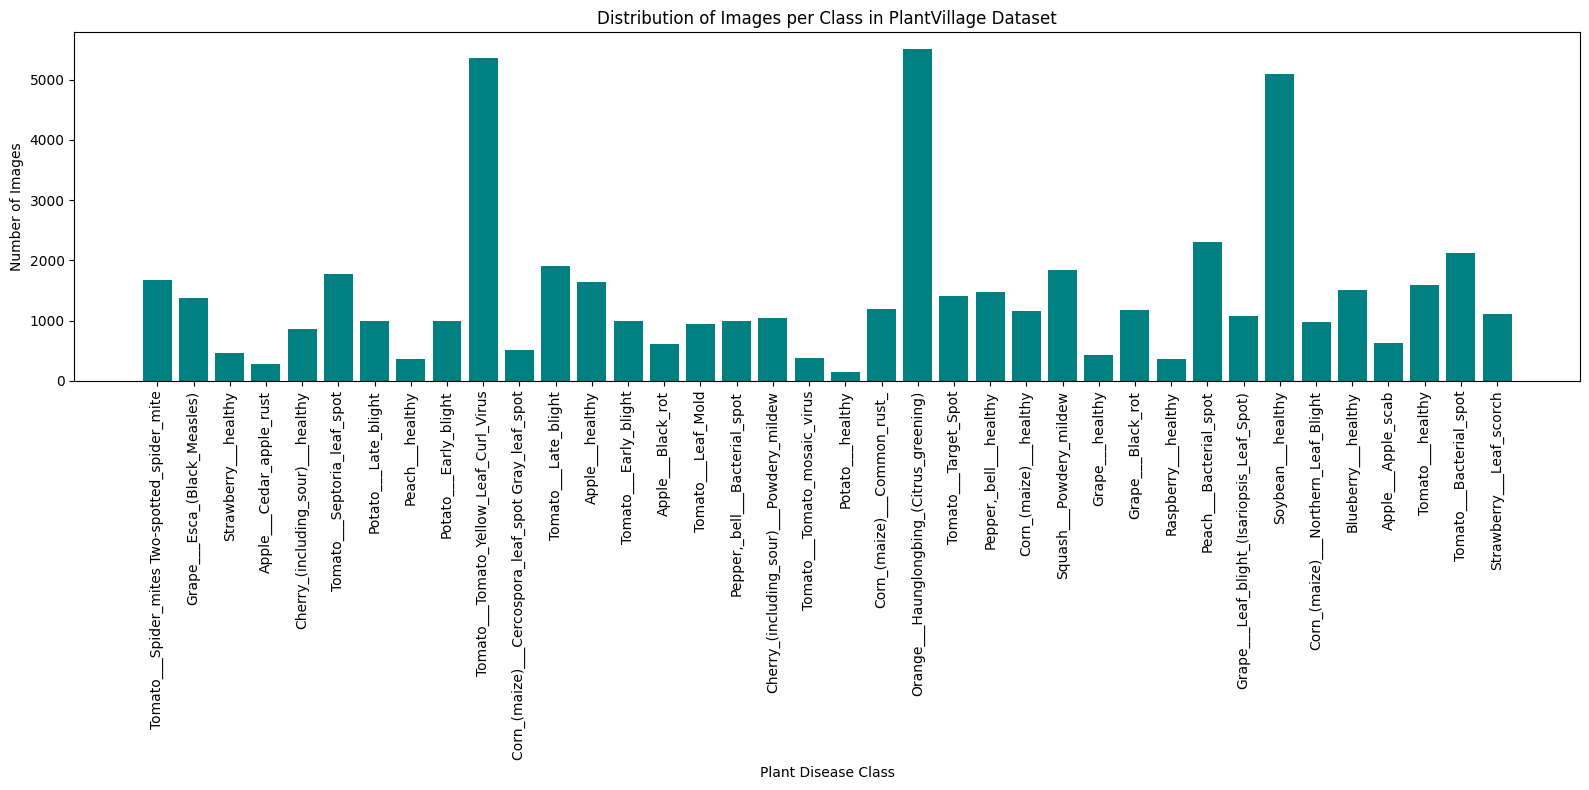

Sample 1 - Class: Tomato___Tomato_mosaic_virus, Width: 256, Height: 256
Sample 2 - Class: Orange___Haunglongbing_(Citrus_greening), Width: 256, Height: 256
Sample 3 - Class: Strawberry___healthy, Width: 256, Height: 256


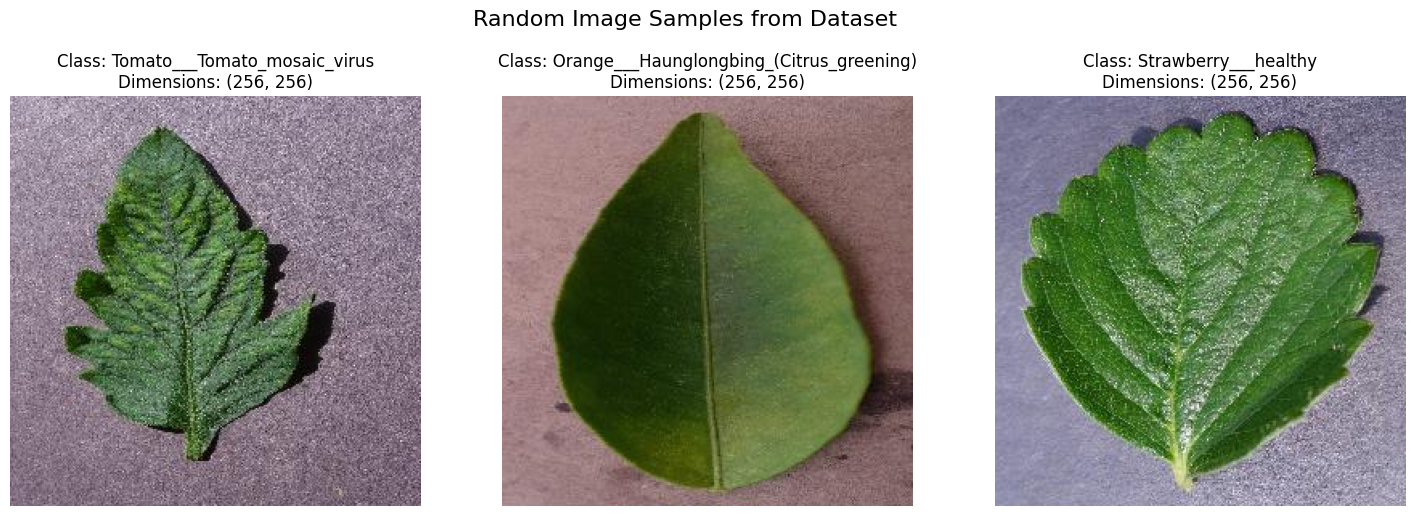

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# 1 & 2. Count images in each class folder from final_color_path
class_distribution = {}
classes = [d for d in os.listdir(final_color_path) if os.path.isdir(os.path.join(final_color_path, d))]

for cls in classes:
    cls_dir = os.path.join(final_color_path, cls)
    # Counting common image formats
    num_images = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    class_distribution[cls] = num_images

# 3. Create a bar chart for class distribution
plt.figure(figsize=(16, 8))
plt.bar(class_distribution.keys(), class_distribution.values(), color='teal')
plt.xticks(rotation=90)
plt.xlabel('Plant Disease Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in PlantVillage Dataset')
plt.tight_layout()
plt.show()

# 4 & 5. Select, display random images and print dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i in range(3):
    random_cls = random.choice(classes)
    cls_dir = os.path.join(final_color_path, random_cls)
    img_name = random.choice([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    img_path = os.path.join(cls_dir, img_name)

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {random_cls}\nDimensions: {img.size}")
    axes[i].axis('off')

    print(f"Sample {i+1} - Class: {random_cls}, Width: {img.width}, Height: {img.height}")

plt.suptitle('Random Image Samples from Dataset', fontsize=16)
plt.show()

## Data Preprocessing and Loading

In [8]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch

# 2. Define transforms (resizing to 64x64, Tensor conversion, and ImageNet normalization)
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Load dataset using ImageFolder
full_dataset = datasets.ImageFolder(root=final_color_path, transform=data_transforms)

# 4. Split into training (80%) and validation (20%) sets with a fixed seed
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

# 5. Create DataLoader instances
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 6. Print verification details
print(f"Total images in dataset: {len(full_dataset)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")

Total images in dataset: 54305
Training samples: 43444
Validation samples: 10861
Number of classes: 38


## Define LIF-based SNN Architecture

In [9]:
import torch
import torch.nn as nn
import snntorch
from snntorch import surrogate
from snntorch import Leaky

# 2. Define a class named SNN that inherits from nn.Module
class SNN(nn.Module):
    def __init__(self, num_classes=38, beta=0.9, num_steps=25):
        super(SNN, self).__init__()

        self.num_steps = num_steps
        spike_grad = surrogate.fast_sigmoid(slope=25)

        # 3 & 4. Define architecture with Conv, MaxPool, Flatten, and Linear layers with LIF neurons
        # First Convolutional Block
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1 = snntorch.Leaky(beta=beta, spike_grad=spike_grad)

        # Second Convolutional Block
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2 = snntorch.Leaky(beta=beta, spike_grad=spike_grad)

        # Flatten and Fully Connected
        self.flatten = nn.Flatten()
        # Input features for Linear: (64-5+1=60)/2=30; (30-5+1=26)/2=13 -> 32*13*13 = 5408
        self.fc1 = nn.Linear(32 * 13 * 13, num_classes)
        self.lif3 = snntorch.Leaky(beta=beta, spike_grad=spike_grad)

    # 5. Implement the forward method to handle temporal dynamics
    def forward(self, x):
        # Initialize hidden states (membrane potentials)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        # Record the final layer spikes
        spk3_rec = []
        mem3_rec = []

        # Iterate through fixed number of time steps
        for step in range(self.num_steps):
            cur1 = self.pool1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc1(self.flatten(spk2))
            spk3, mem3 = self.lif3(cur3, mem3)

            spk3_rec.append(spk3)
            mem3_rec.append(mem3)

        # 6. Return the accumulated spikes and membrane potentials
        return torch.stack(spk3_rec, dim=0), torch.stack(mem3_rec, dim=0)

# Instantiate model and print summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SNN().to(device)
print(model)

SNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif1): Leaky()
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif2): Leaky()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=5408, out_features=38, bias=True)
  (lif3): Leaky()
)


Epoch [1/25], Step [0/679], Loss: 4.8388
Epoch [1/25], Step [100/679], Loss: 2.5278
Epoch [1/25], Step [200/679], Loss: 1.9273
Epoch [1/25], Step [300/679], Loss: 1.7010
Epoch [1/25], Step [400/679], Loss: 1.6374
Epoch [1/25], Step [500/679], Loss: 1.1561
Epoch [1/25], Step [600/679], Loss: 0.8414
Epoch [1/25] completed. Validation Accuracy: 68.84%
Epoch [2/25], Step [0/679], Loss: 1.0153
Epoch [2/25], Step [100/679], Loss: 0.8439
Epoch [2/25], Step [200/679], Loss: 0.6765
Epoch [2/25], Step [300/679], Loss: 0.7933
Epoch [2/25], Step [400/679], Loss: 0.8313
Epoch [2/25], Step [500/679], Loss: 0.6623
Epoch [2/25], Step [600/679], Loss: 0.7248
Epoch [2/25] completed. Validation Accuracy: 76.18%
Epoch [3/25], Step [0/679], Loss: 0.8526
Epoch [3/25], Step [100/679], Loss: 0.6551
Epoch [3/25], Step [200/679], Loss: 0.7029
Epoch [3/25], Step [300/679], Loss: 0.7221
Epoch [3/25], Step [400/679], Loss: 0.7742
Epoch [3/25], Step [500/679], Loss: 0.3501
Epoch [3/25], Step [600/679], Loss: 0.6037

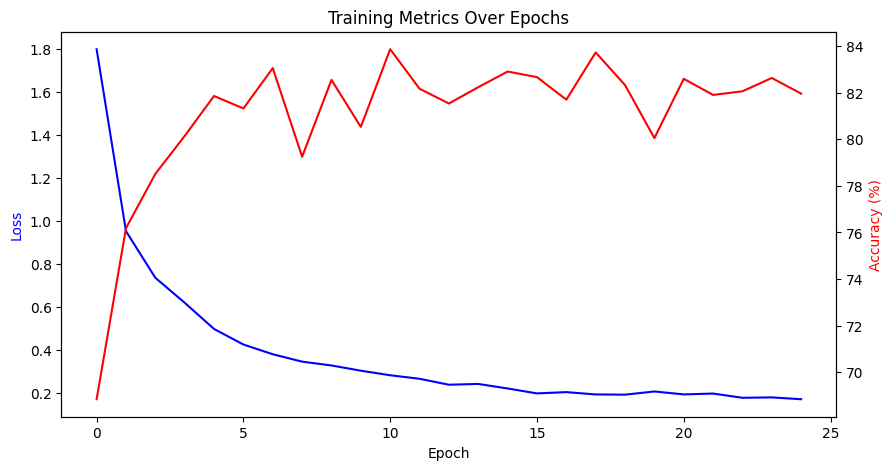

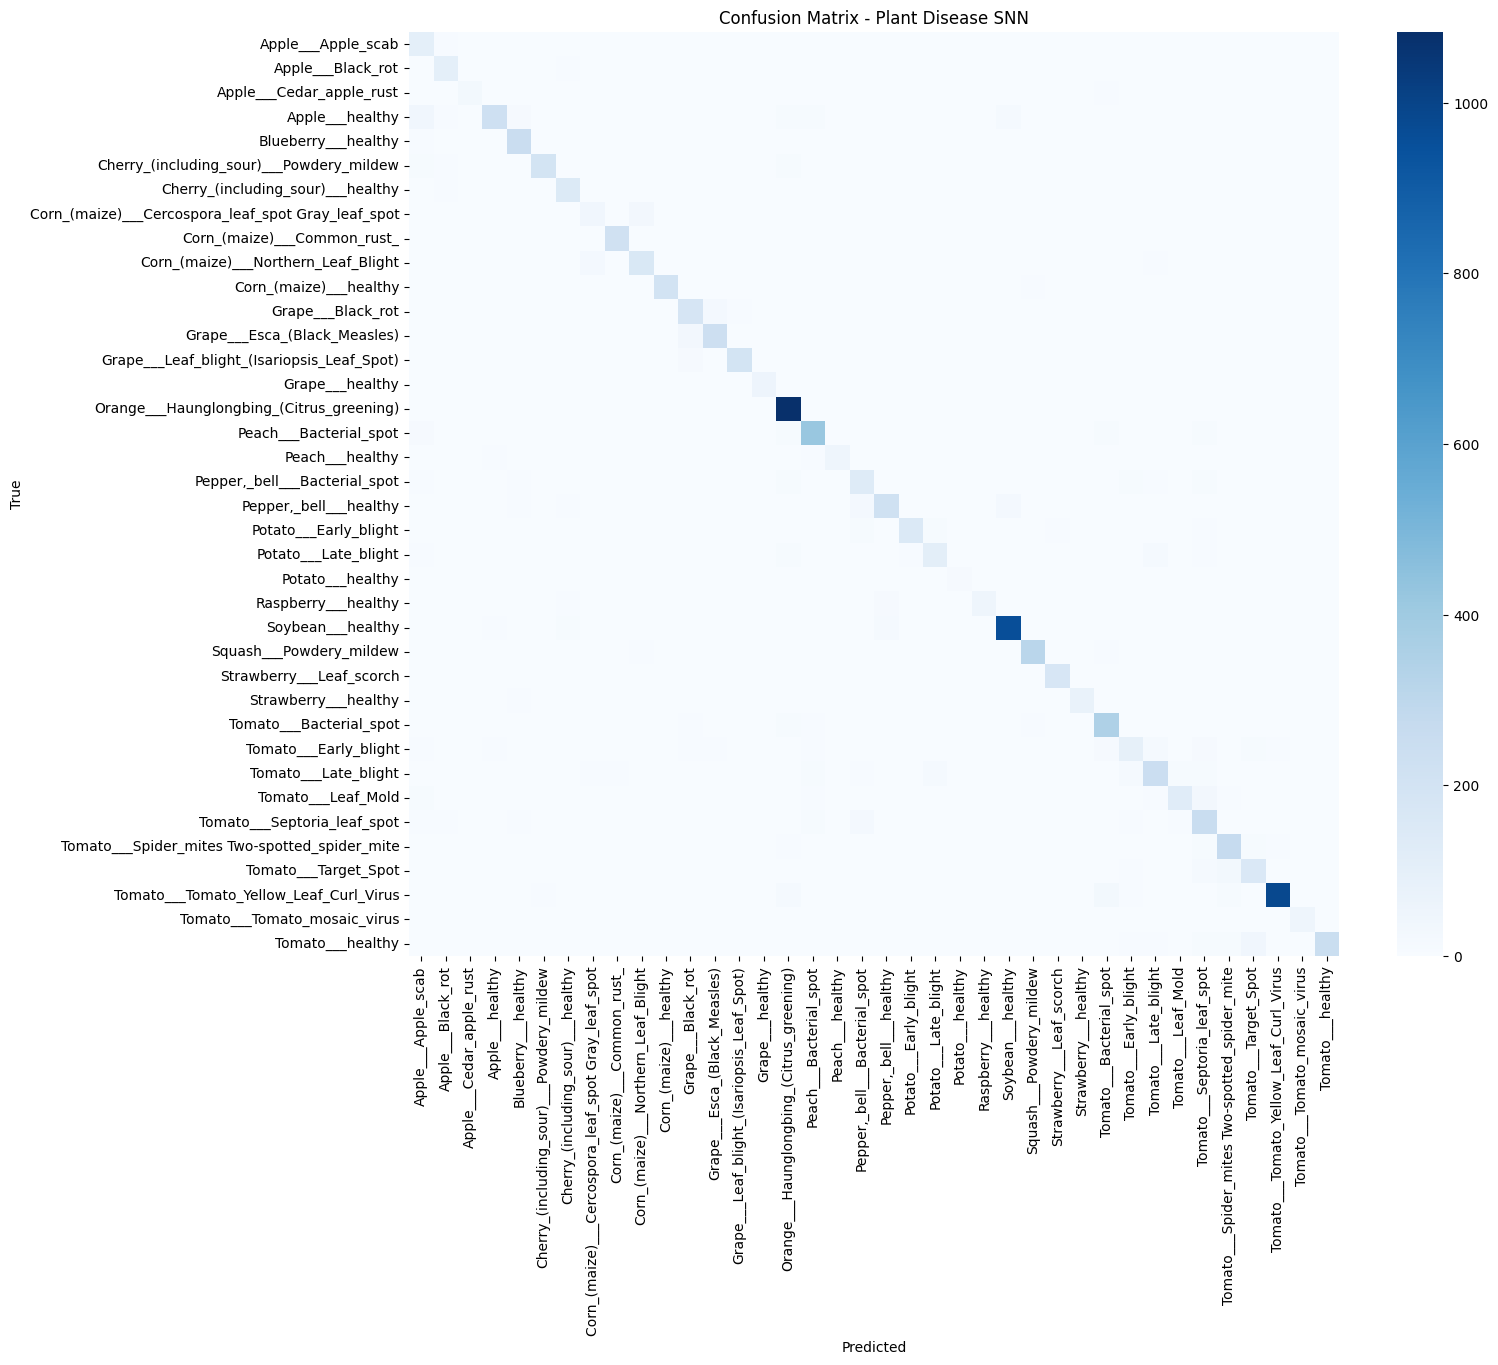

In [10]:
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Define loss function and optimizer
loss_fn = SF.ce_count_loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 25
train_loss_hist = []
val_acc_hist = []

# 2 & 3. Training and Validation Loop
for epoch in range(num_epochs):
    model.train()
    avg_loss = 0
    for i, (data, targets) in enumerate(train_loader):
        data, targets = data.to(device), targets.to(device)

        # Forward pass
        spk_rec, mem_rec = model(data)

        # Loss calculation (using spike counts)
        loss_val = loss_fn(spk_rec, targets)

        # Gradient descent
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        avg_loss += loss_val.item()
        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i}/{len(train_loader)}], Loss: {loss_val.item():.4f}")

    train_loss_hist.append(avg_loss / len(train_loader))

    # Validation accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, targets in val_loader:
            data, targets = data.to(device), targets.to(device)
            spk_rec, _ = model(data)
            _, predicted = spk_rec.sum(dim=0).max(1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    val_acc = 100 * correct / total
    val_acc_hist.append(val_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] completed. Validation Accuracy: {val_acc:.2f}%")

# 4. Plot Training Loss and Validation Accuracy
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(train_loss_hist, 'b-', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='b')
ax2 = ax1.twinx()
ax2.plot(val_acc_hist, 'r-', label='Val Acc')
ax2.set_ylabel('Accuracy (%)', color='r')
plt.title('Training Metrics Over Epochs')
plt.show()

# 5. Confusion Matrix
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for data, targets in val_loader:
        data, targets = data.to(device), targets.to(device)
        spk_rec, _ = model(data)
        _, predicted = spk_rec.sum(dim=0).max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Plant Disease SNN')
plt.xticks(rotation=90)
plt.show()

In [12]:
# ── Save model state_dict for deployment ─────────────────────────────────
import torch
model_save_path = 'LIF_SNN_model_state_dict.pt'
torch.save(model.state_dict(), model_save_path)
print(f"✅  Model state_dict saved to {model_save_path}")

✅  Model state_dict saved to LIF_SNN_model_state_dict.pt


In [13]:
# ── Load model state_dict for deployment ─────────────────────────────────
import torch
loaded_model = SNN().to(device)
model_load_path = 'LIF_SNN_model_state_dict.pt'
loaded_model.load_state_dict(torch.load(model_load_path))
loaded_model.eval()

print(f"✅ Model state_dict loaded successfully from {model_load_path}")

✅ Model state_dict loaded successfully from LIF_SNN_model_state_dict.pt
